In [134]:
import numpy as np
import csv
import os
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

In [183]:
# get data from csv files and convert to numpy array of form (nTrials, nEMGChannels, nTrialLength)
# For a start, consider nTrialLength of 200 time steps of EMG (100ms)

# For y data, just use ankle angle at the end of the trial for now
# Thus array is of form (nTrials, 1)

#note: we don't actually know how many trials we have yet .. for now assume 300
# and chop off any unused at the end
# (come up with something more elegant later)
nTrials = 5000
nTrialLen = 20
nEMGChannels = 64
factor_EMGlen2AnkleLen = 20 # sampling rate of emg is 20x higher than ankle data

X_data = np.zeros((nTrials,nEMGChannels, nTrialLen))
Y_data = np.zeros((nTrials, 2))
iTrial = 0

dataDir = "/content/"

# add for loop to go through all emg files for this subj
for fileName in os.listdir(dataDir):
  if fileName.startswith("EMG_Proc"):
    # load file from processed emg files
    emgFileData = np.loadtxt(dataDir + fileName, dtype=float, delimiter=",")
    # get data from corresponding ankle file
    ankleFileName = "Ankle" + fileName[8:]
    ankleFileData = np.loadtxt(dataDir + ankleFileName, dtype=float, delimiter=",")

    # iterate through EMG file and pull out non-overlapping segments of length
    # nTrialLen and add them to X_data
    # also pull out ankle angle for matching time step and add to Y_data
    nFileLen = emgFileData.shape[0]
    iTrialStart = 0
    while (iTrialStart + nTrialLen) < nFileLen:
      X_data[iTrial, :, :] = np.transpose(emgFileData[iTrialStart:iTrialStart+nTrialLen, :])
      Y_data[iTrial,:] = ankleFileData[int((iTrialStart+nTrialLen) / factor_EMGlen2AnkleLen),:]
      iTrial += 1
      iTrialStart += nTrialLen

In [184]:
nTrials = iTrial
# now we know how many trials there are .. remove unused trials from data array
X_data = X_data[:nTrials, :, :]
Y_data = Y_data[:nTrials, :]

In [185]:
# create test/train split for this data
X_train, X_test, Y_train, Y_test = train_test_split(
    X_data, Y_data, test_size=0.2, random_state=13)

In [186]:
# Reshape x datasets to feed into model
X_train = X_train.reshape(X_train.shape[0], 1, X_train.shape[1], X_train.shape[2])
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1], X_test.shape[2])

In [187]:
print(Y_train.shape)

(2979, 2)


# Define Model

For now, just make a super simple CNN to see if we can train on this data

In [38]:
keras.backend.set_image_data_format('channels_first')

In [39]:


input_shape = (1, nEMGChannels, nTrialLen)
input = keras.Input(shape=(input_shape))
layer = keras.layers.Conv2D(8, (1, 64), padding='same', use_bias=True, input_shape=input_shape)(input)
layer = keras.layers.MaxPooling2D(pool_size=4)(layer)
layer = keras.layers.Conv2D(8, (1, 16), padding='same', use_bias=True)(layer)
layer = keras.layers.Flatten()(layer)
layer = keras.layers.Dense(64, activation='sigmoid')(layer)
mod_out = keras.layers.Dense(1, activation='sigmoid')(layer)

model = keras.Model(inputs=input, outputs=mod_out)


In [188]:

input_shape = (1, nEMGChannels, nTrialLen)

model = keras.Sequential()
model.add(keras.Input(shape=input_shape))
#model.add(Dense(256, activation='relu', input_dim=366))
model.add(keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Conv2D(16, (3, 3), activation='relu', padding='same'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Conv2D(16, (3, 3), activation='relu', padding='same'))
model.add(keras.layers.BatchNormalization())

model.add(keras.layers.MaxPooling2D(pool_size=(2, 2)))

model.add(keras.layers.Flatten())

#model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dropout(0.2))

#model.add(keras.layers.Dense(256, activation='relu'))
model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dense(32, activation='relu'))
model.add(keras.layers.Dense(16, activation='relu'))

model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(2, activation='linear'))


In [189]:
model.summary()
model.compile(loss=keras.losses.MeanSquaredError, optimizer= keras.optimizers.Adam(learning_rate=0.001), metrics=["mean_squared_error"])

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_70 (Conv2D)              │ (None, 64, 64, 20)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 64, 64, 20)     │            80 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_71 (Conv2D)              │ (None, 16, 64, 20)     │         9,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 16, 64, 20)     │            80 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_72 (Conv2D)              │ (None, 16, 64, 20)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 16, 64, 20)     │            80 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 16, 32, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_25 (Flatten)            │ (None, 5120)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 5120)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 64)             │       327,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_78 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 342,818 (1.31 MB)

 Trainable params: 342,698 (1.31 MB)

 Non-trainable params: 120 (480.00 B)

In [190]:
hist = model.fit(X_train, Y_train, batch_size=64, shuffle=True, epochs=100, validation_split=0.125)

Epoch 1/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 11s 131ms/step - loss: 520.2728 - mean_squared_error: 520.2728 - val_loss: 383.1905 - val_mean_squared_error: 383.1905
Epoch 2/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 249.1425 - mean_squared_error: 249.1425 - val_loss: 345.3942 - val_mean_squared_error: 345.3942
Epoch 3/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 230.3021 - mean_squared_error: 230.3021 - val_loss: 308.5635 - val_mean_squared_error: 308.5635
Epoch 4/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 203.3447 - mean_squared_error: 203.3447 - val_loss: 233.7969 - val_mean_squared_error: 233.7969
Epoch 5/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 173.8840 - mean_squared_error: 173.8840 - val_loss: 238.0029 - val_mean_squared_error: 238.0029
Epoch 6/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 152.3010 - mean_squared_error: 152.3010 - val_loss: 213.4520 - val_mean_squared_error: 213.4520
Epoch 7/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 132.

In [191]:
y_pred = model.predict(X_test)

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step


R2 score for angle: 0.6068671269764042


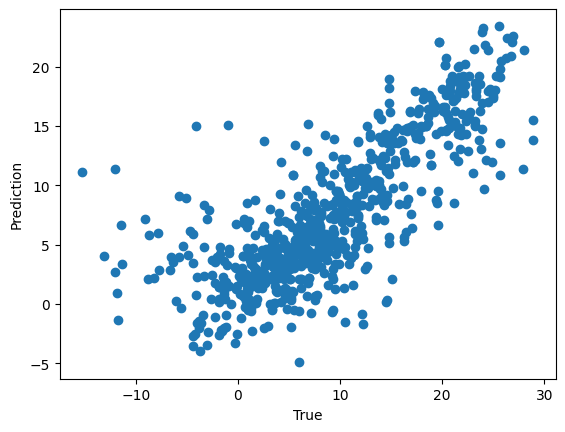

In [192]:
plt.scatter(Y_test[:,0], y_pred[:,0])
plt.ylabel("Prediction")
plt.xlabel("True")
print("R2 score for angle: " + str(r2_score(Y_test[:,0], y_pred[:,0])))

R2 score for torque: 0.7739535777866865


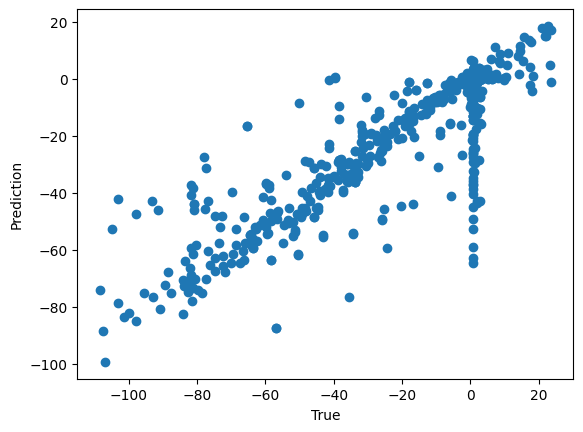

In [193]:
plt.scatter(Y_test[:,1], y_pred[:,1])
plt.ylabel("Prediction")
plt.xlabel("True")
print("R2 score for torque: " + str(r2_score(Y_test[:,1], y_pred[:,1])))

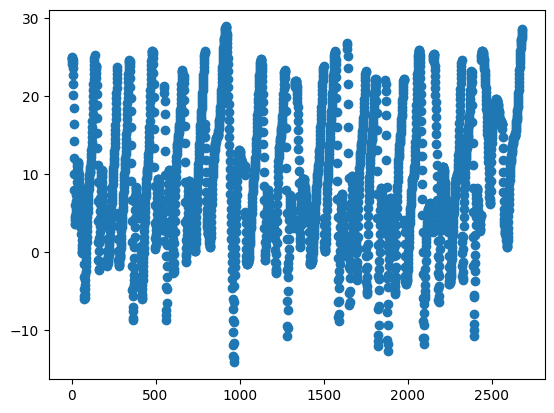

In [99]:
plt.scatter(np.arange(nTrials), Y_data)